# get results

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [2]:
def calculate_auroc_from_csv(file_path):
    """Calculate AUROC for a single CSV file"""
    try:
        # Load the CSV file
        df = pd.read_csv(file_path)

        # Check if the required columns exist
        required_columns = ['type', 'mean_score']
        if not all(col in df.columns for col in required_columns):
            return None, "Missing required columns (type and/or mean_score)"

        # Prepare data for ROC calculation
        # 1 for deployment (positive class), 0 for testing (negative class)
        y_true = (df['type'] == 'deployment').astype(int)

        # Use mean_score as the prediction score
        y_score = df['mean_score']

        # Calculate ROC curve points
        fpr, tpr, thresholds = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        # Calculate optimal threshold (Youden's J statistic)
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = thresholds[optimal_idx]
        sensitivity = tpr[optimal_idx]
        specificity = 1-fpr[optimal_idx]

        return {
            'auroc': roc_auc,
            'optimal_threshold': optimal_threshold,
            'sensitivity': sensitivity,
            'specificity': specificity
        }, None

    except Exception as e:
        return None, str(e)

In [3]:
def process_all_csvs_in_directory(directory_path):
    """Process all CSV files in the given directory"""
    results = {}

    # Check if directory exists
    if not os.path.isdir(directory_path):
        print(f"Error: '{directory_path}' is not a valid directory.")
        return results

    # Get list of CSV files
    csv_files = [f for f in os.listdir(directory_path) if f.endswith('.csv')]

    if not csv_files:
        print(f"No CSV files found in {directory_path}")
        return results

    print(f"Found {len(csv_files)} CSV files in {directory_path}")
    print(f"{'File Name':<40} {'AUROC':<10} {'Threshold':<10} {'Sensitivity':<12} {'Specificity':<12}")
    print("-" * 90)

    # Process each CSV file
    for file_name in csv_files:
        file_path = os.path.join(directory_path, file_name)
        stats, error = calculate_auroc_from_csv(file_path)

        if error:
            print(f"{file_name:<40} Error: {error}")
        else:
            auroc = stats['auroc']
            threshold = stats['optimal_threshold']
            sensitivity = stats['sensitivity']
            specificity = stats['specificity']

            print(f"{file_name:<40} {auroc:.4f}    {threshold:.4f}    {sensitivity:.4f}      {specificity:.4f}")
            results[file_name] = stats

    # Find and print the file with the highest AUROC
    if results:
        # Peak AUROC
        best_file = max(results.items(), key=lambda x: x[1]['auroc'])
        print("\nHighest AUROC:")
        print(f"File: {best_file[0]}, AUROC: {best_file[1]['auroc']:.4f}")

        # Mean AUROC across all layers
        all_aurocs = [v['auroc'] for v in results.values()]
        mean_auroc = np.mean(all_aurocs)
        std_auroc = np.std(all_aurocs)
        peak_auroc = best_file[1]['auroc']
        concentration_ratio = peak_auroc / mean_auroc if mean_auroc > 0 else float('inf')

        print(f"\nSummary Statistics:")
        print(f"  Mean AUROC:          {mean_auroc:.4f} (std: {std_auroc:.4f})")
        print(f"  Peak AUROC:          {peak_auroc:.4f}")
        print(f"  Peak/Mean ratio:     {concentration_ratio:.3f}")
        print(f"  (ratio > 1 = signal concentrated at peak layer)")
        print(f"  (ratio near 1 = signal diffuse across all layers)")

    return results

In [4]:
directory_path = 'qwen2.5_1.5b_test/'
results = process_all_csvs_in_directory(directory_path)

Found 23 CSV files in qwen2.5_1.5b_test/
File Name                                AUROC      Threshold  Sensitivity  Specificity 
------------------------------------------------------------------------------------------
probe_stats_layer20.csv                  0.7011    -2.7130    0.4650      0.9100
probe_stats_layer21.csv                  0.6110    0.2767    0.4600      0.7650
probe_stats_layer23.csv                  0.5798    -1.2512    0.8300      0.3150
probe_stats_layer22.csv                  0.5314    0.4819    0.3250      0.8500
probe_stats_layer19.csv                  0.6277    -1.5231    0.4600      0.8400
probe_stats_layer18.csv                  0.6834    -2.1813    0.4500      0.9400
probe_stats_layer4.csv                   0.4244    5.7601    0.0850      0.9850
probe_stats_layer5.csv                   0.4388    0.0373    0.9950      0.1100
probe_stats_layer7.csv                   0.4022    5.4836    0.0850      0.9800
probe_stats_layer6.csv                   0.4139    3.45

In [ ]:
# Load the data
df = pd.read_csv('./QWEN_0.5B_PROBE_RESULTS/probe_stats_layer9.csv')

# Prepare data for ROC calculation
y_true = (df['type'] == 'deployment').astype(int)
y_score = df['mean_score']

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# Create wider figure
plt.figure(figsize=(12, 6))

# Plot the ROC curve
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.3f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")

# Add text box with metrics
metrics_text = f'AUROC: {0.816}\nThreshold: {0.103}\nSensitivity: {0.690}\nSpecificity: {0.860}'
plt.text(0.05, 0.95, metrics_text,
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', edgecolor='black', alpha=0.8),
         verticalalignment='top',
         fontfamily='monospace')

# Save as PDF
plt.savefig('roc_curve.pdf', format='pdf', bbox_inches='tight', dpi=300)

# Save as SVG
plt.savefig('roc_curve.svg', format='svg', bbox_inches='tight')

# Display the plot
plt.show()

## Black Box Vs White Box

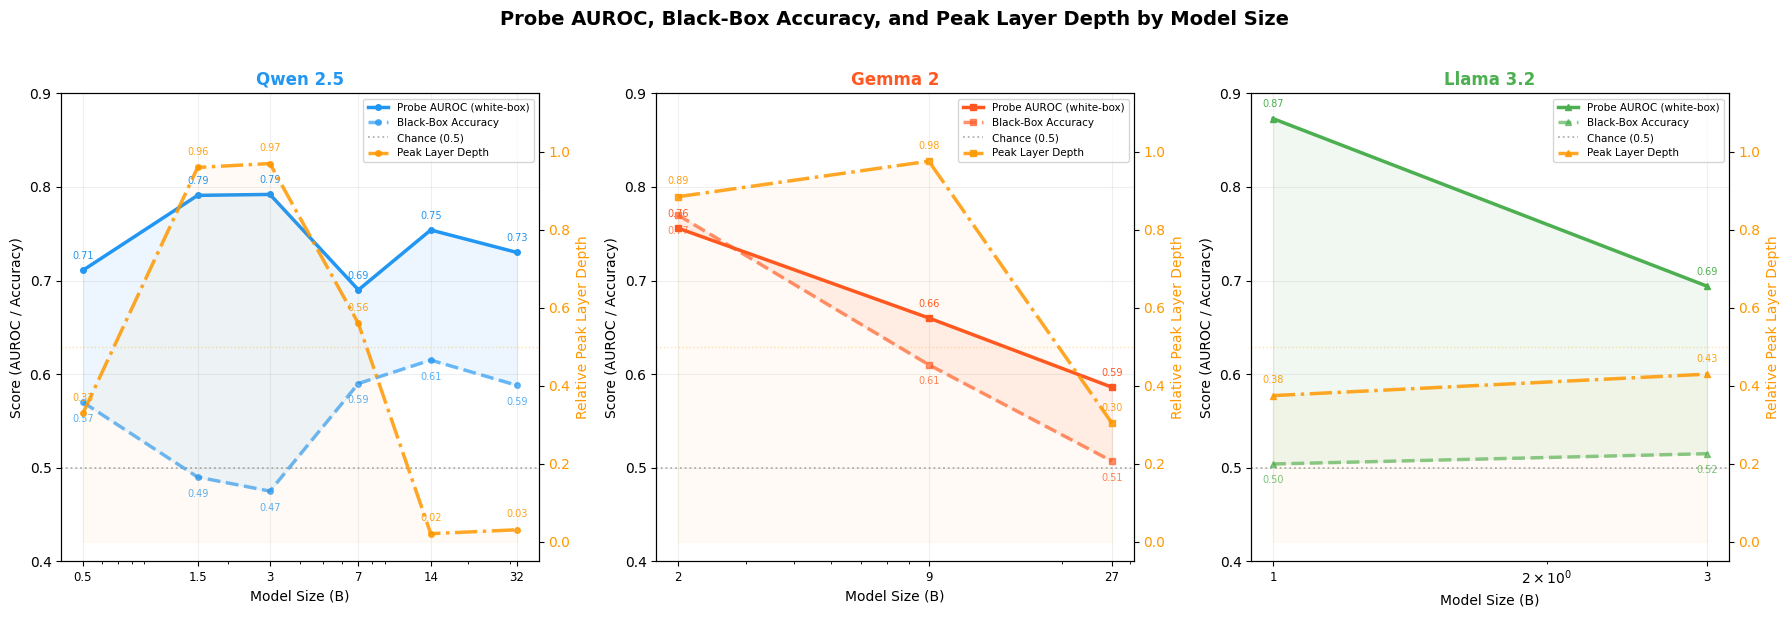

Saved as probe_blackbox_depth_by_family.png


In [17]:
import matplotlib.pyplot as plt
import numpy as np

data = {
    'Qwen 2.5': {
        'sizes':      [0.5,  1.5,  3,     7,    14,    32],
        'peak_auroc': [0.711, 0.791, 0.792, 0.690, 0.754, 0.730],
        'black_box':  [0.570, 0.490, 0.475, 0.590, 0.615, 0.588],
        'peak_depth': [0.33,  0.96,  0.97,  0.56,  0.021, 0.031],
    },
    'Gemma 2': {
        'sizes':      [2,     9,     27],
        'peak_auroc': [0.756, 0.660, 0.586],
        'black_box':  [0.770, 0.610, 0.507],
        'peak_depth': [0.885, 0.976, 0.304],
    },
    'Llama 3.2': {
        'sizes':      [1,     3],
        'peak_auroc': [0.873, 0.694],
        'black_box':  [0.504, 0.515],
        'peak_depth': [0.375, 0.430],
    },
}

colors  = {'Qwen 2.5': '#2196F3', 'Gemma 2': '#FF5722', 'Llama 3.2': '#4CAF50'}
markers = {'Qwen 2.5': 'o',       'Gemma 2': 's',       'Llama 3.2': '^'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Probe AUROC, Black-Box Accuracy, and Peak Layer Depth by Model Size',
    fontsize=14, fontweight='bold', y=1.02
)

for ax, (family, d) in zip(axes, data.items()):
    col = colors[family]
    mk  = markers[family]
    sizes = d['sizes']

    # ── Left y-axis: AUROC and black-box accuracy ──
    # Changed markersize from 9 to 4 here
    ax.plot(sizes, d['peak_auroc'], marker=mk, color=col,
            linewidth=2.5, markersize=4, linestyle='-',
            label='Probe AUROC (white-box)', zorder=3)
    ax.plot(sizes, d['black_box'], marker=mk, color=col,
            linewidth=2.5, markersize=4, linestyle='--', alpha=0.65,
            label='Black-Box Accuracy', zorder=3)
    ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1.3,
               alpha=0.6, label='Chance (0.5)')
    ax.fill_between(sizes, d['peak_auroc'], d['black_box'],
                    alpha=0.08, color=col)

    # Annotate accuracy values
    for s, a, b in zip(sizes, d['peak_auroc'], d['black_box']):
        ax.annotate(f'{a:.2f}', (s, a), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=7, color=col)
        ax.annotate(f'{b:.2f}', (s, b), textcoords='offset points',
                    xytext=(0, -14), ha='center', fontsize=7,
                    color=col, alpha=0.75)

    ax.set_ylim(0.40, 0.90)
    ax.set_ylabel('Score (AUROC / Accuracy)', fontsize=10)
    ax.set_xlabel('Model Size (B)', fontsize=10)

    # ── Right y-axis: peak layer depth ──────────────
    ax2 = ax.twinx()
    # Changed markersize from 9 to 4 here as well
    ax2.plot(sizes, d['peak_depth'], marker=mk, color='#FF9800',
             linewidth=2.5, markersize=4, linestyle='-.',
             label='Peak Layer Depth', zorder=2, alpha=0.85)
    ax2.fill_between(sizes, d['peak_depth'], 0,
                     alpha=0.04, color='#FF9800')

    # Annotate depth values
    for s, dep in zip(sizes, d['peak_depth']):
        ax2.annotate(f'{dep:.2f}', (s, dep), textcoords='offset points',
                     xytext=(0, 9), ha='center', fontsize=7,
                     color='#FF9800', alpha=0.9)

    ax2.set_ylim(-0.05, 1.15)
    ax2.set_ylabel('Relative Peak Layer Depth', fontsize=10, color='#FF9800')
    ax2.tick_params(axis='y', labelcolor='#FF9800')
    ax2.axhline(y=0.5, color='#FF9800', linestyle=':', linewidth=1,
                alpha=0.3)

    # ── Formatting ───────────────────────────────────
    ax.set_xscale('log')
    ax.set_xticks(sizes)
    ax.set_xticklabels([str(s) for s in sizes], fontsize=8.5)
    ax.grid(True, alpha=0.2)
    ax.set_title(family, fontsize=12, fontweight='bold', color=col)

    # Combined legend from both axes
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2,
              fontsize=7.5, loc='upper right')

plt.tight_layout()
plt.savefig('probe_blackbox_depth_by_family.png', dpi=150,
            bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print("Saved as probe_blackbox_depth_by_family.png")

## Phase Transition

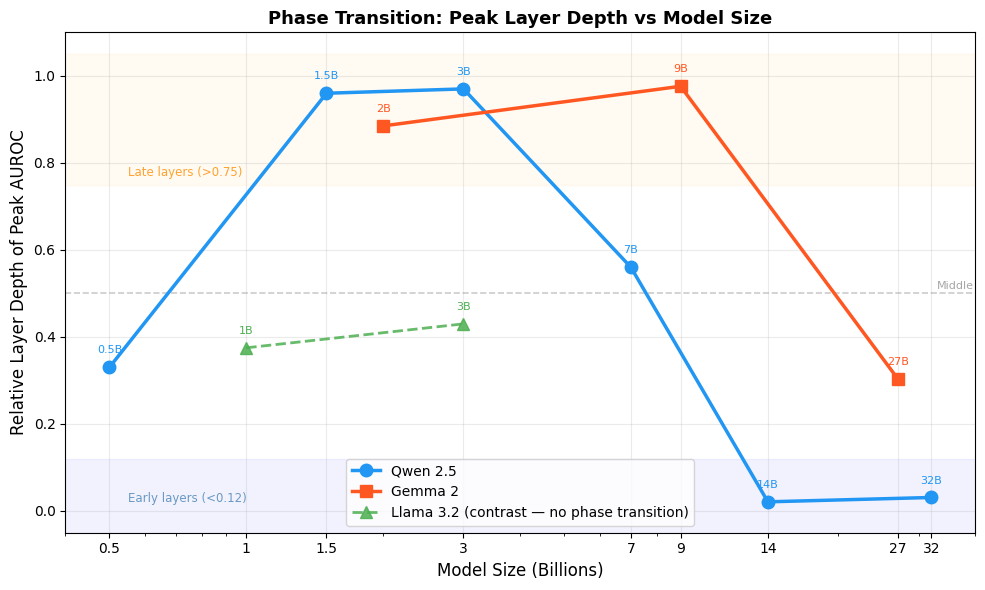

Saved as phase_transition_with_llama.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

qwen_data = {
    'sizes': [0.5, 1.5, 3, 7, 14, 32],
    'peak_depth': [0.33, 0.96, 0.97, 0.56, 0.021, 0.031],
}
gemma_data = {
    'sizes': [2, 9, 27],
    'peak_depth': [0.885, 0.976, 0.304],
}
llama_data = {
    'sizes': [1, 3],
    'peak_depth': [0.375, 0.430],
}

qwen_color  = '#2196F3'
gemma_color = '#FF5722'
llama_color = '#4CAF50'

fig, ax1 = plt.subplots(figsize=(10, 6))

# Qwen
ax1.plot(qwen_data['sizes'], qwen_data['peak_depth'],
         'o-', color=qwen_color, linewidth=2.5, markersize=9,
         label='Qwen 2.5', zorder=3)
for s, d in zip(qwen_data['sizes'], qwen_data['peak_depth']):
    ax1.annotate(f'{s}B', (s, d), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=8, color=qwen_color)

# Gemma
ax1.plot(gemma_data['sizes'], gemma_data['peak_depth'],
         's-', color=gemma_color, linewidth=2.5, markersize=9,
         label='Gemma 2', zorder=3)
for s, d in zip(gemma_data['sizes'], gemma_data['peak_depth']):
    ax1.annotate(f'{s}B', (s, d), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=8, color=gemma_color)

# Llama
ax1.plot(llama_data['sizes'], llama_data['peak_depth'],
         '^--', color=llama_color, linewidth=2.0, markersize=9,
         label='Llama 3.2 (contrast — no phase transition)', zorder=3, alpha=0.85)
for s, d in zip(llama_data['sizes'], llama_data['peak_depth']):
    ax1.annotate(f'{s}B', (s, d), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=8, color=llama_color)

# Background shading
ax1.fill_between([0.1, 100], 0.75, 1.05, alpha=0.05, color='orange')
ax1.fill_between([0.1, 100], -0.05, 0.12, alpha=0.05, color='blue')
ax1.text(0.55, 0.77, 'Late layers (>0.75)', fontsize=8.5,
         color='darkorange', alpha=0.8)
ax1.text(0.55, 0.02, 'Early layers (<0.12)', fontsize=8.5,
         color='steelblue', alpha=0.8)

# Midpoint reference
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1.2)
ax1.text(33, 0.51, 'Middle', fontsize=8, color='gray', alpha=0.7)

ax1.set_xscale('log')
ax1.set_xlabel('Model Size (Billions)', fontsize=12)
ax1.set_ylabel('Relative Layer Depth of Peak AUROC', fontsize=12)
ax1.set_title('Phase Transition: Peak Layer Depth vs Model Size',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10, loc='lower center')
ax1.set_ylim(-0.05, 1.10)
ax1.set_xlim(0.4, 40)
ax1.set_xticks([0.5, 1, 1.5, 3, 7, 9, 14, 27, 32])
ax1.set_xticklabels(['0.5', '1', '1.5', '3', '7', '9', '14', '27', '32'])
ax1.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('phase_transition_with_llama.png', dpi=150,
            bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print("Saved as phase_transition_with_llama.png")

## No Universal Power Law

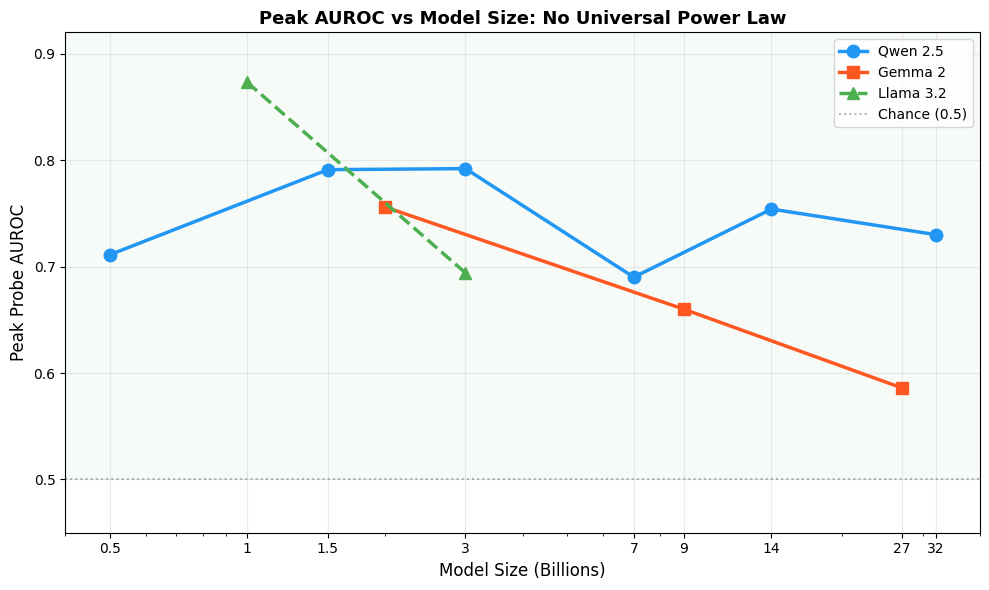

Saved as peak_auroc_vs_size.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

data = {
    'Qwen 2.5': {
        'sizes':      [0.5,  1.5,  3,     7,    14,    32],
        'peak_auroc': [0.711, 0.791, 0.792, 0.690, 0.754, 0.730],
    },
    'Gemma 2': {
        'sizes':      [2,     9,     27],
        'peak_auroc': [0.756, 0.660, 0.586],
    },
    'Llama 3.2': {
        'sizes':      [1,     3],
        'peak_auroc': [0.873, 0.694],
    },
}

colors  = {'Qwen 2.5': '#2196F3', 'Gemma 2': '#FF5722', 'Llama 3.2': '#4CAF50'}
markers = {'Qwen 2.5': 'o',       'Gemma 2': 's',       'Llama 3.2': '^'}
lines   = {'Qwen 2.5': '-',       'Gemma 2': '-',       'Llama 3.2': '--'}

fig, ax = plt.subplots(figsize=(10, 6))

for family, d in data.items():
    ax.plot(d['sizes'], d['peak_auroc'],
            marker=markers[family],
            color=colors[family],
            linestyle=lines[family],
            linewidth=2.5,
            markersize=9,
            label=family,
            zorder=3)

# Chance baseline
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1.4,
           alpha=0.6, label='Chance (0.5)')

# Shading to highlight above-chance region
ax.fill_between([0.1, 100], 0.5, 0.95, alpha=0.03, color='green')

ax.set_xscale('log')
ax.set_xlabel('Model Size (Billions)', fontsize=12)
ax.set_ylabel('Peak Probe AUROC', fontsize=12)
ax.set_title('Peak AUROC vs Model Size: No Universal Power Law',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0.45, 0.92)
ax.set_xlim(0.4, 40)
ax.set_xticks([0.5, 1, 1.5, 3, 7, 9, 14, 27, 32])
ax.set_xticklabels(['0.5', '1', '1.5', '3', '7', '9', '14', '27', '32'])
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('peak_auroc_vs_size.png', dpi=150,
            bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print("Saved as peak_auroc_vs_size.png")

## Black Box vs White Box #2

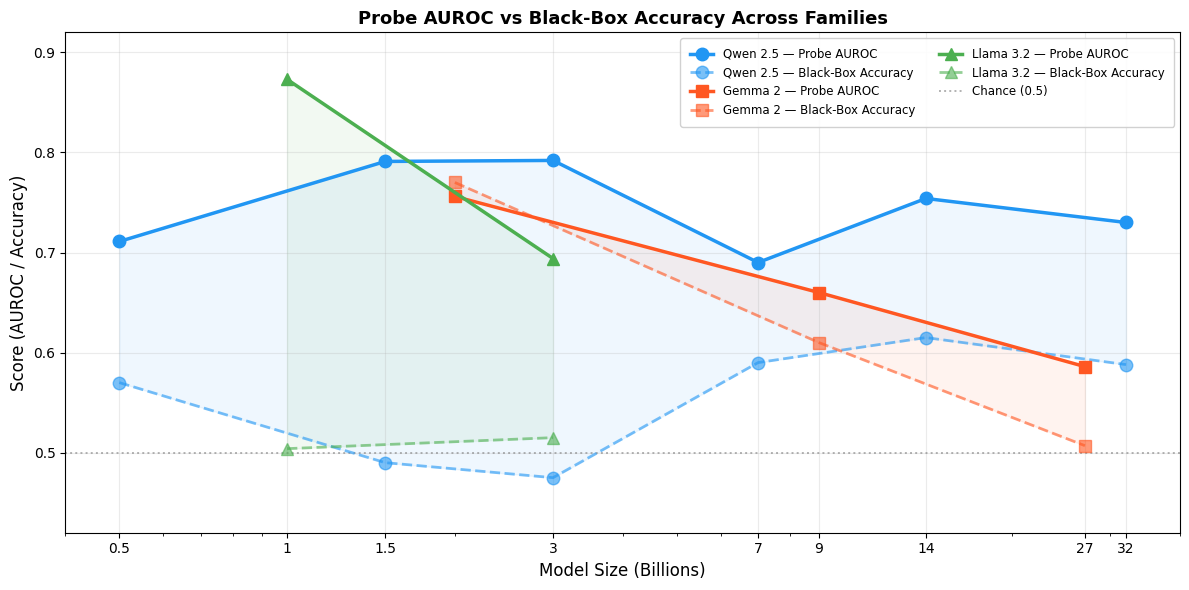

Saved as whitebox_vs_blackbox_combined.png


In [2]:
import matplotlib.pyplot as plt
import numpy as np

data = {
    'Qwen 2.5': {
        'sizes':      [0.5,  1.5,  3,     7,    14,    32],
        'peak_auroc': [0.711, 0.791, 0.792, 0.690, 0.754, 0.730],
        'black_box':  [0.570, 0.490, 0.475, 0.590, 0.615, 0.588],
    },
    'Gemma 2': {
        'sizes':      [2,     9,     27],
        'peak_auroc': [0.756, 0.660, 0.586],
        'black_box':  [0.770, 0.610, 0.507],
    },
    'Llama 3.2': {
        'sizes':      [1,     3],
        'peak_auroc': [0.873, 0.694],
        'black_box':  [0.504, 0.515],
    },
}

colors  = {'Qwen 2.5': '#2196F3', 'Gemma 2': '#FF5722', 'Llama 3.2': '#4CAF50'}
markers = {'Qwen 2.5': 'o',       'Gemma 2': 's',       'Llama 3.2': '^'}

fig, ax = plt.subplots(figsize=(12, 6))

for family, d in data.items():
    col = colors[family]
    mk  = markers[family]
    sizes = d['sizes']

    # Probe AUROC — solid line
    ax.plot(sizes, d['peak_auroc'],
            marker=mk, color=col, linewidth=2.5, markersize=9,
            linestyle='-', label=f'{family} — Probe AUROC', zorder=3)

    # Black-box accuracy — dashed line, same colour, lighter
    ax.plot(sizes, d['black_box'],
            marker=mk, color=col, linewidth=2.0, markersize=9,
            linestyle='--', alpha=0.6,
            label=f'{family} — Black-Box Accuracy', zorder=3)

    # Shade the gap between the two lines
    ax.fill_between(sizes, d['peak_auroc'], d['black_box'],
                    alpha=0.07, color=col)

    # Annotate probe AUROC values
    # for s, a in zip(sizes, d['peak_auroc']):
    #     ax.annotate(f'{a:.2f}', (s, a),
    #                 textcoords='offset points', xytext=(0, 9),
    #                 ha='center', fontsize=7.5, color=col)

    # Annotate black-box values
    # for s, b in zip(sizes, d['black_box']):
    #     ax.annotate(f'{b:.2f}', (s, b),
    #                 textcoords='offset points', xytext=(0, -14),
    #                 ha='center', fontsize=7.5, color=col, alpha=0.85)

# Chance baseline
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1.4,
           alpha=0.6, label='Chance (0.5)')

ax.set_xscale('log')
ax.set_xlabel('Model Size (Billions)', fontsize=12)
ax.set_ylabel('Score (AUROC / Accuracy)', fontsize=12)
ax.set_title('Probe AUROC vs Black-Box Accuracy Across Families',
             fontsize=13, fontweight='bold')

ax.set_ylim(0.42, 0.92)
ax.set_xlim(0.4, 40)
ax.set_xticks([0.5, 1, 1.5, 3, 7, 9, 14, 27, 32])
ax.set_xticklabels(['0.5', '1', '1.5', '3', '7', '9', '14', '27', '32'])
ax.grid(True, alpha=0.25)

# Clean legend — group by family using a two-column layout
ax.legend(fontsize=8.5, loc='upper right', ncol=2,
          framealpha=0.9, borderpad=0.8)

plt.tight_layout()
plt.savefig('whitebox_vs_blackbox_combined.png', dpi=150,
            bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print("Saved as whitebox_vs_blackbox_combined.png")